In [1]:
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import pandas as pd
df= pd.read_csv('us_masters_admission_competitiveness - LMS.csv')
df

,student_id,ug_gpa,ug_university_tier,ug_major,academic_consistency_score,number_of_backlogs,gre_quant,gre_verbal,gre_awa,english_test_type,...,application_completeness_score,intended_specialization,target_university_ranking_band,application_round,visa_dependency,gap_years,linkedin_profile_views,counselling_sessions_attended,preferred_application_city,admission_competitiveness
0,STU100000,6.322932,Tier 3,Maths,5.233771,0,146.898434,157.785905,3.692059,TOEFL,...,6.841625,Robotics,Top 100,Fall,Yes,1,155.263306,2,Pune,1
1,STU100001,8.197611,Tier 2,Maths,6.154830,0,168.862448,141.291206,3.101230,TOEFL,...,7.013050,ECE,Top 50,Fall,Yes,0,78.827282,1,Hyderabad,0
2,STU100002,7.554681,Tier 2,Mechanical,6.615851,0,166.237295,149.474721,3.744999,IELTS,...,7.335025,Mgmt,Above 100,Fall,Yes,0,45.306956,0,Mumbai,1
3,STU100003,5.944335,Tier 3,EEE,5.083298,0,157.873564,149.231949,3.561192,IELTS,...,7.108434,Robotics,Top 100,Fall,Yes,0,107.616752,2,Hyderabad,0
4,STU100004,6.779260,Tier 2,ECE,7.763144,0,151.626238,147.796173,4.246855,TOEFL,...,7.938240,CyberSec,Top 100,Fall,Yes,0,154.615518,3,Bangalore,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,STU105195,7.456580,Tier 2,CS,NaN,0,143.603953,154.800771,3.465706,IELTS,...,6.578899,DS,Top 100,Fall,Yes,1,20.470127,2,Bangalore,1
5196,STU105196,7.874266,Tier 3,IT,5.776024,1,147.684148,150.233066,4.063162,IELTS,...,7.440317,Mgmt,Top 50,Fall,Yes,0,16.273363,1,Chennai,1
5197,STU105197,6.771948,Tier 2,Maths,7.173461,2,154.390174,150.685717,2.950855,TOEFL,...,7.008591,Mgmt,Top 100,Fall,Yes,2,130.427120,1,Hyderabad,1
5198,STU105198,7.613712,Tier 1,ECE,5.881137,1,161.464393,167.463865,3.455576,IELTS,...,7.657892,Mgmt,Top 100,Fall,Yes,3,28.800962,5,Delhi,0


In [2]:
df.isnull().sum()

student_id                          0
ug_gpa                              0
ug_university_tier                  0
ug_major                            0
academic_consistency_score        228
number_of_backlogs                  0
gre_quant                           0
gre_verbal                          0
gre_awa                           220
english_test_type                   0
english_proficiency_score           0
work_experience_months              0
project_count                       0
research_exposure_level             0
internship_relevance_score        247
field_alignment_score               0
sop_quality_score                   0
lor_strength_score                219
resume_strength_score             238
career_goal_clarity_score           0
application_completeness_score      0
intended_specialization             0
target_university_ranking_band      0
application_round                   0
visa_dependency                     0
gap_years                           0
linkedin_pro

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df['academic_consistency_score'].unique()

array([5.23377132, 6.1548302 , 6.61585128, ..., 7.17346061, 5.88113652,
       6.50781588], shape=(4930,))

Q1) Exploratory Data Analysis (5 Marks)
Perform exploratory data analysis on the given dataset and answer the following:
●	Analyze the distribution of the target variable and comment on class balance
●	Analyze at least three categorical features and summarize key observations
●	Identify patterns that differentiate Competitive and Non-Competitive student profiles
Support your findings with suitable visualizations and explanations.


In [5]:
#1) 
df['admission_competitiveness'].value_counts()


admission_competitiveness
0    3640
1    1560
Name: count, dtype: int64

<Axes: xlabel='admission_competitiveness', ylabel='count'>

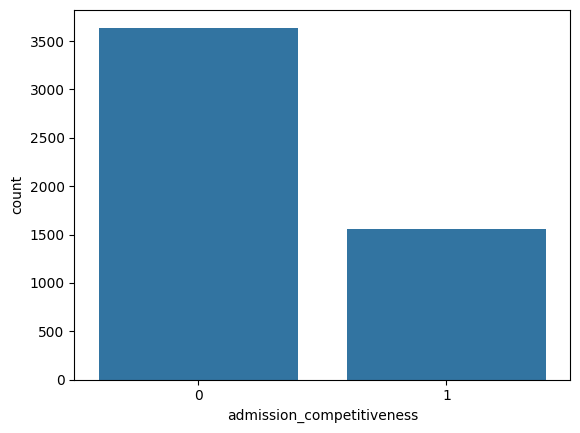

In [6]:
sns.countplot(x='admission_competitiveness',data =df)

Explanation:
Class 0 (Non-Competitive) has 3640 records.
Class 1 (Competitive) has 1560 records.
The dataset is imbalanced because Class 0 contains more records than Class 1 (approximately 70% vs 30%).
This imbalance can affect model performance, so techniques like SMOTE can be applied during model training

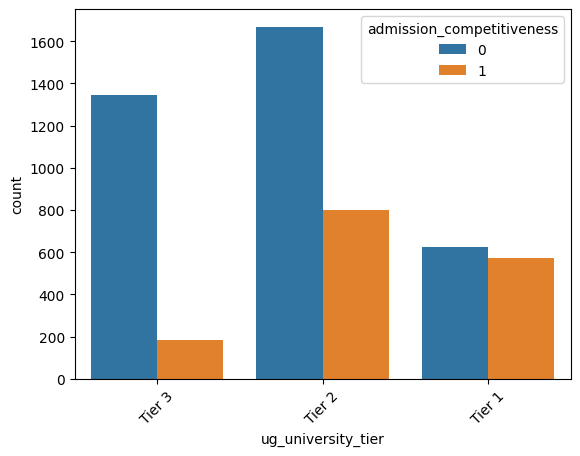

In [7]:
#2)
sns.countplot(data=df, x='ug_university_tier', hue='admission_competitiveness')
plt.xticks(rotation=45)
plt.show()

Students from higher-tier universities are more likely to have competitive profiles

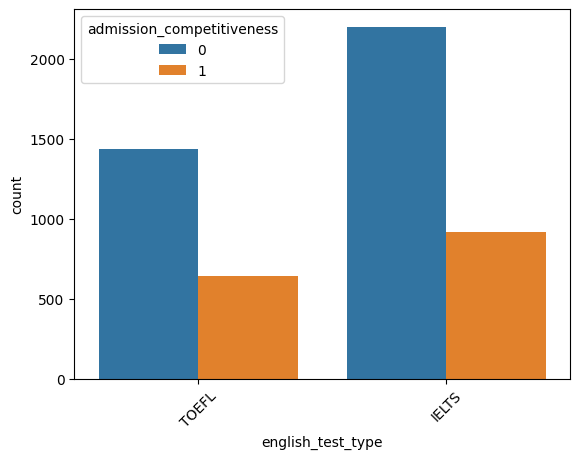

In [8]:
sns.countplot(data=df, x='english_test_type', hue='admission_competitiveness')
plt.xticks(rotation=45)
plt.show()

Compare IELTS and TOEFL students.
Check whether one exam has more competitive students

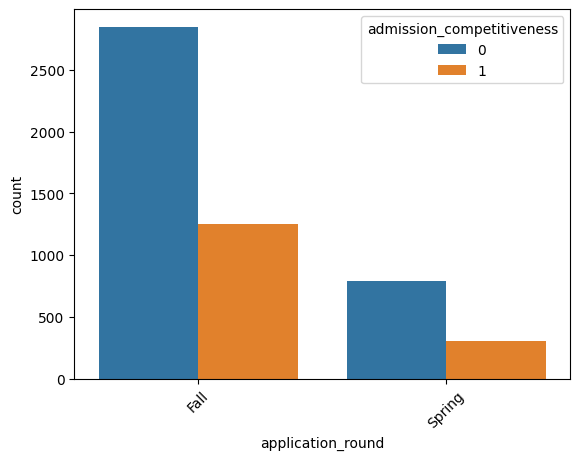

In [9]:
sns.countplot(data=df, x='application_round', hue='admission_competitiveness')
plt.xticks(rotation=45)
plt.show()

Students applying in earlier rounds may have a better chance of admission competitiveness

#3) 
Competitive students generally have:

Higher UG GPA
Higher GRE scores
Better SOP quality

Non-Competitive students generally have:

Lower academic scores
More backlogs

-------------------------------------------------------------------------------

Q2. Data Preprocessing and Feature Engineering (12 Marks)
Perform the following tasks:
a)	Data Cleaning (3 Marks)
●	Identify missing values in the dataset
●	Apply appropriate strategies to handle missing values and justify your approach

b)	Feature Handling (4 Marks)
●	Identify and remove features that should not be used for model training
●	Encode categorical variables using suitable encoding techniques

c)	 Feature Scaling (2 Marks)
●	Apply an appropriate feature scaling or standardization technique
●	Justify why scaling is required for certain machine learning models

d)	Feature Selection (3 Marks)
●	Use a tree-based model to identify important features
●	Comment on the most influential factors affecting admission competitiveness



In [10]:
#a)
df.isnull().sum()

student_id                          0
ug_gpa                              0
ug_university_tier                  0
ug_major                            0
academic_consistency_score        228
number_of_backlogs                  0
gre_quant                           0
gre_verbal                          0
gre_awa                           220
english_test_type                   0
english_proficiency_score           0
work_experience_months              0
project_count                       0
research_exposure_level             0
internship_relevance_score        247
field_alignment_score               0
sop_quality_score                   0
lor_strength_score                219
resume_strength_score             238
career_goal_clarity_score           0
application_completeness_score      0
intended_specialization             0
target_university_ranking_band      0
application_round                   0
visa_dependency                     0
gap_years                           0
linkedin_pro

In [11]:

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())



mode - categorical(object) 
median - numerical(int)

In [12]:
#b 
df.drop('student_id', axis=1, inplace=True)

It has no relationship with the target variable.It does not help the model make predictions.

In [13]:
for i in df.select_dtypes(include='object').columns:
    print(i)
    l=LabelEncoder()
    df[i] = l.fit_transform(df[i])

ug_university_tier
ug_major
english_test_type
intended_specialization
target_university_ranking_band
application_round
visa_dependency
preferred_application_city


In [14]:
#c)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = df.drop('admission_competitiveness', axis=1)
y = df['admission_competitiveness']

x_scaled = scaler.fit_transform(x)


Scaling is used to bring the values into same range(-3 to +3)

In [15]:
#d)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_scaled, y)

importance = pd.Series(rf.feature_importances_, index=x.columns)

importance.sort_values(ascending=False)


sop_quality_score                 0.116146
lor_strength_score                0.083993
field_alignment_score             0.078941
ug_university_tier                0.065310
internship_relevance_score        0.065006
resume_strength_score             0.058270
academic_consistency_score        0.047082
ug_gpa                            0.038933
english_proficiency_score         0.038715
gre_verbal                        0.038251
gre_quant                         0.037574
application_completeness_score    0.036737
career_goal_clarity_score         0.036296
linkedin_profile_views            0.035724
work_experience_months            0.035562
gre_awa                           0.034829
project_count                     0.019474
number_of_backlogs                0.019262
ug_major                          0.019167
counselling_sessions_attended     0.017066
intended_specialization           0.016699
preferred_application_city        0.016063
target_university_ranking_band    0.011658
research_ex

sop_quality_score - is the most important feature because it has the highest feature importance score.
lor_strength_score - is the second most important feature.
resume_strength_score :also has a significant influence on admission competitiveness.

In [16]:
#3)
# before calling the logistic regression ,we need to define x and y and train the data

from sklearn.model_selection import train_test_split

x = df.drop('admission_competitiveness', axis=1)
y = df['admission_competitiveness']

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

80% of the data is used for training.
20% is used for testing.
The model learns from the training data and is evaluated on the testing data.

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train, y_train)
train = lr.score(x_train, y_train)
print(train)

lr_pred = lr.predict(x_test)

0.8247596153846154


Logistic Regression is used for binary classification problems.
The target variable has two classes (0 and 1) and works for classification model

In [18]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

confusion_mat = confusion_matrix(y_test, lr_pred)
print('Confusion Matrix:\n', confusion_mat)

accuracy = accuracy_score(y_test, lr_pred)
print('Accuracy:\n', accuracy)

class_rep = classification_report(y_test, lr_pred)
print('Classification Report:\n', class_rep)

Confusion Matrix:
 [[655  67]
 [118 200]]
Accuracy:
 0.8221153846153846
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       722
           1       0.75      0.63      0.68       318

    accuracy                           0.82      1040
   macro avg       0.80      0.77      0.78      1040
weighted avg       0.82      0.82      0.82      1040



In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)
train = dt.score(x_train, y_train)
print(train)

dt_pred = dt.predict(x_test)

1.0


**Suitability of Decision Tree**

Decision Tree is suitable because it can capture non-linear relationships between features and the target variable. It handles both numerical and categorical data effectively and provides an interpretable structure showing how decisions are made. It also performs feature selection automatically during training.

In [20]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

confusion_mat1 = confusion_matrix(y_test, dt_pred)
print('Confusion Matrix:\n', confusion_mat1)

accuracy1 = accuracy_score(y_test, dt_pred)
print('Accuracy:\n', accuracy1)

class_rep1 = classification_report(y_test, dt_pred)
print('Classification Report:\n', class_rep1)

Confusion Matrix:
 [[586 136]
 [161 157]]
Accuracy:
 0.7144230769230769
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       722
           1       0.54      0.49      0.51       318

    accuracy                           0.71      1040
   macro avg       0.66      0.65      0.66      1040
weighted avg       0.71      0.71      0.71      1040



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)
train = rf.score(x_train, y_train)
print(train)

rf_pred = rf.predict(x_test)

1.0


**Suitability of Random Forest**

Random Forest is suitable because it combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is robust to noisy data, handles large datasets effectively, and provides feature importance scores that help identify the most influential factors affecting admission competitiveness.

In [22]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

confusion_mat12 = confusion_matrix(y_test, rf_pred)
print('Confusion Matrix:\n', confusion_mat12)

accuracy12 = accuracy_score(y_test, rf_pred)
print('Accuracy:\n', accuracy12)

class_rep12 = classification_report(y_test, rf_pred)
print('Classification Report:\n', class_rep12)

Confusion Matrix:
 [[685  37]
 [194 124]]
Accuracy:
 0.7778846153846154
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.95      0.86       722
           1       0.77      0.39      0.52       318

    accuracy                           0.78      1040
   macro avg       0.77      0.67      0.69      1040
weighted avg       0.78      0.78      0.75      1040



SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [24]:
log1 = LogisticRegression()
log1.fit(x_train_res, y_train_res)
train1 = log1.score(x_train_res, y_train_res)
print(train1)
logistic_regression_predict1 = log1.predict(x_test)
logistic_regression_predict1

0.8145990404386566


array([0, 0, 0, ..., 0, 1, 0], shape=(1040,))

In [25]:
confusion_mat1 = confusion_matrix(y_test, logistic_regression_predict1)
print('Confusion Matrix:\n', confusion_mat1)

accuracy1 = accuracy_score(y_test, logistic_regression_predict1)
print('Accuracy:\n', accuracy1)

class_rep1 = classification_report(y_test, logistic_regression_predict1)
print('Classification Report:\n', class_rep1)

Confusion Matrix:
 [[568 154]
 [ 59 259]]
Accuracy:
 0.7951923076923076
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.79      0.84       722
           1       0.63      0.81      0.71       318

    accuracy                           0.80      1040
   macro avg       0.77      0.80      0.78      1040
weighted avg       0.82      0.80      0.80      1040



In [26]:
rf1 = RandomForestClassifier()
rf1.fit(x_train_res, y_train_res)
rf_train1 = rf1.score(x_train_res, y_train_res)
print(rf_train1)
rf_predict1 = rf1.predict(x_test)
rf_predict1

1.0


array([0, 0, 0, ..., 0, 0, 0], shape=(1040,))

In [27]:
rf_confusion_mat1 = confusion_matrix(y_test, rf_predict1)
print('Confusion Matrix:\n', rf_confusion_mat1)

rf_accuracy1 = accuracy_score(y_test, rf_predict1)
print('Accuracy:\n', rf_accuracy1)

rf_class_rep1 = classification_report(y_test, rf_predict1)
print('Classification Report:\n', rf_class_rep1)

Confusion Matrix:
 [[642  80]
 [133 185]]
Accuracy:
 0.7951923076923076
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       722
           1       0.70      0.58      0.63       318

    accuracy                           0.80      1040
   macro avg       0.76      0.74      0.75      1040
weighted avg       0.79      0.80      0.79      1040



●	Identify the best-performing model and justify your selection based on results
On my prediction ,Logistic regression is the best model compared to random forest and decision tree .After using smote ,logistics regression predicted less ,while before using smote ,the logistic regression is considered as best model ,So using smote does not improve model

In [28]:
df1 = pd.read_csv('zomato_user_data - LMS.csv')
df1

,user_id,city,device_type,subscription_status,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
0,ZOM200000,Hyderabad,iOS,NaN,Returning,North Indian,26.740168,8.965961,8.465340,4.815482,...,0.355390,0.629073,0.326298,0.451233,0.525325,8.390026,32.193597,0.019575,4.362833,0
1,ZOM200001,Kolkata,iOS,NaN,Returning,Chinese,10.145544,6.343538,10.526948,0.276121,...,0.227851,0.005544,0.643287,0.000000,0.434892,26.205100,26.341917,0.068982,4.295368,2
2,ZOM200002,Kolkata,Android,Zomato Gold,Returning,Italian,23.190429,7.971666,12.844486,3.517156,...,0.523863,0.338718,0.446290,0.250970,0.606698,13.669060,28.575752,0.049404,4.543003,0
3,ZOM200003,Hyderabad,Android,Zomato Gold,Returning,South Indian,13.083080,6.911308,9.543095,2.315705,...,0.342982,0.717055,0.215513,0.401037,0.628076,20.310362,21.667125,0.040058,4.286456,0
4,ZOM200004,Bangalore,Android,NaN,Long-Term,Desserts,61.488038,16.936118,5.490302,19.726369,...,0.279026,0.199145,0.292876,0.374529,0.398572,3.435409,40.145218,0.104421,3.827626,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3635,ZOM202264,Delhi,iOS,Zomato Gold,New,Italian,16.481160,6.920860,12.773472,2.574076,...,0.703973,0.774749,0.572077,0.303654,0.622002,19.209666,44.512947,0.042912,4.251407,1
3636,ZOM202495,Chennai,Android,NaN,New,North Indian,40.574472,7.051855,4.863000,7.176181,...,0.226026,0.406253,0.425289,0.208317,0.471751,2.424156,30.268877,0.067409,3.702781,0
3637,ZOM202996,Pune,Android,Zomato Gold,Long-Term,South Indian,63.754776,11.935378,3.689744,20.923686,...,0.128175,0.334203,0.475938,0.388242,0.523828,4.490520,44.566969,0.038015,4.003085,0
3638,ZOM201496,Mumbai,iOS,Zomato Gold,Long-Term,South Indian,9.131585,3.840038,10.893734,6.403263,...,0.352540,0.760576,0.447815,0.298614,0.497469,20.776154,21.995036,0.048466,4.796810,0


Q1. Exploratory Data Analysis (EDA) (4 Marks)
Perform exploratory data analysis on the given dataset and address the following points:
●	Analyze the distribution of key numerical features related to user engagement and ordering behavior

●	Analyze at least three categorical variables such as city, device type, subscription status, or preferred cuisine
●	Summarize key observations that indicate differences in user usage patterns
●	Support your analysis with appropriate visualizations and explanations.


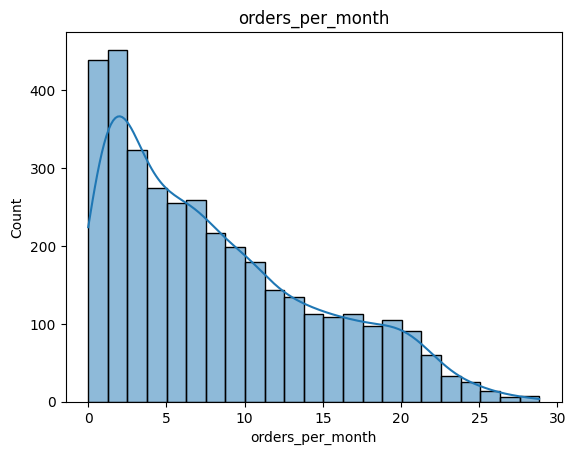

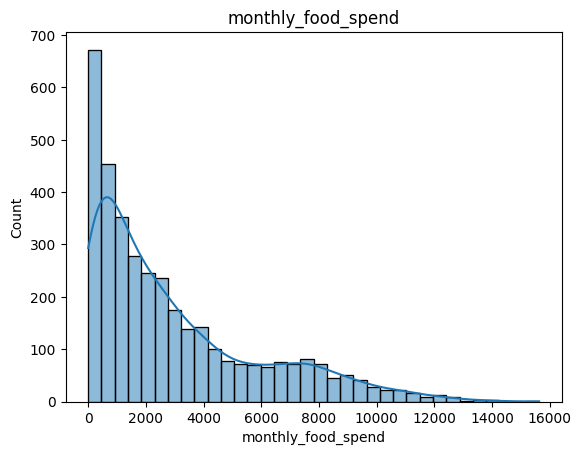

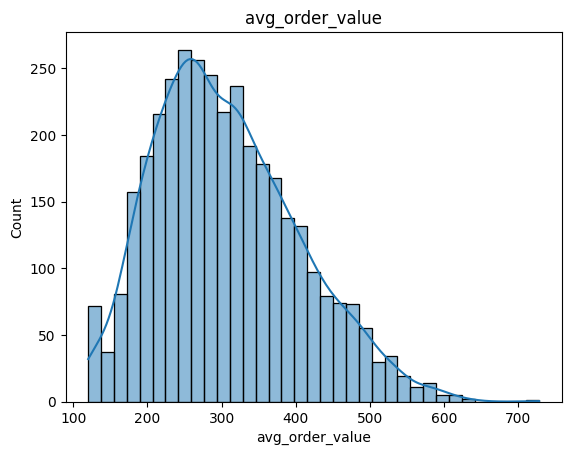

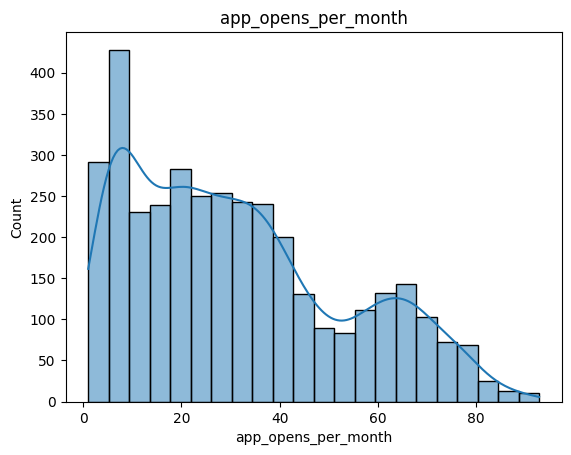

In [29]:
num = ['orders_per_month',
       'monthly_food_spend',
       'avg_order_value',
       'app_opens_per_month']

for i in num:
    sns.histplot(df1[i], kde=True)
    plt.title(i)
    plt.show()

Most users place a moderate number of orders.
Very few users place extremely high numbers of orders.

Monthly Food Spend

Most users spend a moderate amount on food.
A few users have very high monthly spending.

Average Order Value

Most users have similar order values.
Some users place high-value orders.

App Opens per Month

Most users open the app frequently.
A few users are highly active

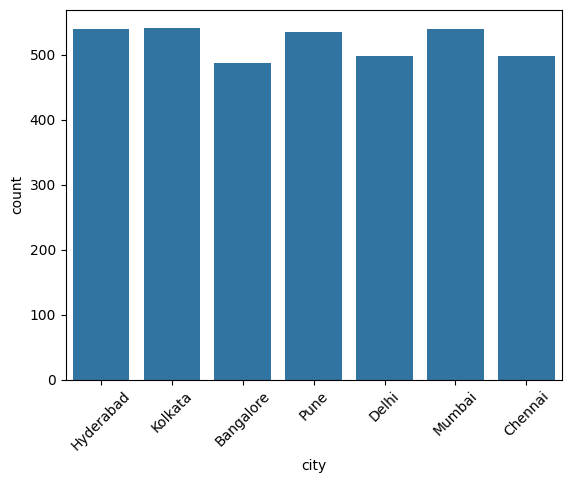

In [30]:
sns.countplot(data=df1,
              x='city')
plt.xticks(rotation=45)
plt.show()

Some cities have more active users than others

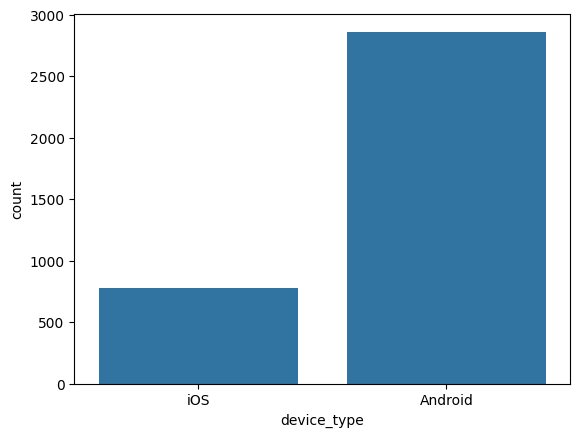

In [31]:
sns.countplot(data=df1,
              x='device_type')
plt.show()

Android users are more than iOS users

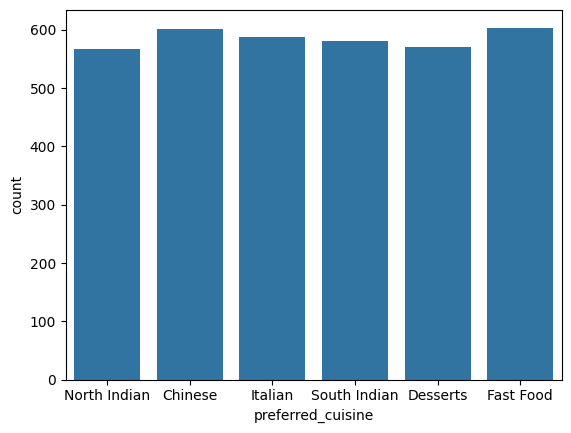

In [32]:
sns.countplot(data=df1,
              x='preferred_cuisine')
plt.show()

both chinese and fast food are high compared to others

c)Compare the spending pattern of subscribed and non-subscribed users.
If subscribed users have a higher median, they tend to spend more.
If both groups have similar medians, subscription has little impact on spending.
Outliers represent users with unusually high monthly spending

d)Most users place a moderate number of monthly orders.
Food spending varies among users, with a few high spenders.
User distribution differs across cities.
Both Android and iOS users actively use the application

In [33]:
df1.isnull().sum()

user_id                             0
city                                0
device_type                         0
subscription_status              2435
user_segment_label                  0
preferred_cuisine                 128
app_opens_per_month                 0
avg_session_duration_minutes        0
browse_sessions_without_order       0
orders_per_month                    0
avg_order_value                   125
monthly_food_spend                  0
discount_usage_rate               117
promo_orders_ratio                  0
weekend_order_ratio                 0
late_night_orders_ratio             0
peak_hour_orders_ratio              0
days_since_last_order               0
avg_delivery_time_minutes         116
order_cancellation_rate             0
app_rating_given                    0
customer_support_chats              0
dtype: int64

In [34]:
df1.drop('subscription_status',axis=1,inplace=True)
df1

,user_id,city,device_type,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,avg_order_value,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
0,ZOM200000,Hyderabad,iOS,Returning,North Indian,26.740168,8.965961,8.465340,4.815482,339.180816,...,0.355390,0.629073,0.326298,0.451233,0.525325,8.390026,32.193597,0.019575,4.362833,0
1,ZOM200001,Kolkata,iOS,Returning,Chinese,10.145544,6.343538,10.526948,0.276121,204.398439,...,0.227851,0.005544,0.643287,0.000000,0.434892,26.205100,26.341917,0.068982,4.295368,2
2,ZOM200002,Kolkata,Android,Returning,Italian,23.190429,7.971666,12.844486,3.517156,258.724471,...,0.523863,0.338718,0.446290,0.250970,0.606698,13.669060,28.575752,0.049404,4.543003,0
3,ZOM200003,Hyderabad,Android,Returning,South Indian,13.083080,6.911308,9.543095,2.315705,198.966084,...,0.342982,0.717055,0.215513,0.401037,0.628076,20.310362,21.667125,0.040058,4.286456,0
4,ZOM200004,Bangalore,Android,Long-Term,Desserts,61.488038,16.936118,5.490302,19.726369,475.915562,...,0.279026,0.199145,0.292876,0.374529,0.398572,3.435409,40.145218,0.104421,3.827626,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3635,ZOM202264,Delhi,iOS,New,Italian,16.481160,6.920860,12.773472,2.574076,273.832386,...,0.703973,0.774749,0.572077,0.303654,0.622002,19.209666,44.512947,0.042912,4.251407,1
3636,ZOM202495,Chennai,Android,New,North Indian,40.574472,7.051855,4.863000,7.176181,333.488809,...,0.226026,0.406253,0.425289,0.208317,0.471751,2.424156,30.268877,0.067409,3.702781,0
3637,ZOM202996,Pune,Android,Long-Term,South Indian,63.754776,11.935378,3.689744,20.923686,378.554457,...,0.128175,0.334203,0.475938,0.388242,0.523828,4.490520,44.566969,0.038015,4.003085,0
3638,ZOM201496,Mumbai,iOS,Long-Term,South Indian,9.131585,3.840038,10.893734,6.403263,NaN,...,0.352540,0.760576,0.447815,0.298614,0.497469,20.776154,21.995036,0.048466,4.796810,0


In [35]:
for i in df1.columns:

    if df1[i].dtype != 'object':
        df1[i] = df1[i].fillna(df1[i].median())

    else:
        df1[i] = df1[i].fillna(df1[i].mode()[0])

In [36]:
df1.duplicated().sum()

np.int64(53)

In [37]:
df1.drop_duplicates(inplace=True)

Index(['app_opens_per_month', 'avg_session_duration_minutes',
       'browse_sessions_without_order', 'orders_per_month', 'avg_order_value',
       'monthly_food_spend', 'discount_usage_rate', 'promo_orders_ratio',
       'weekend_order_ratio', 'late_night_orders_ratio',
       'peak_hour_orders_ratio', 'days_since_last_order',
       'avg_delivery_time_minutes', 'order_cancellation_rate',
       'app_rating_given', 'customer_support_chats'],
      dtype='object')


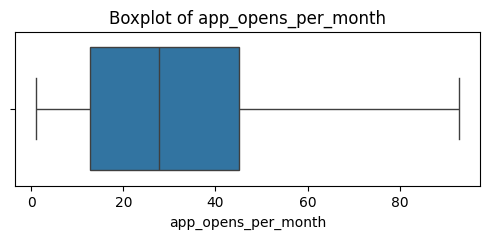

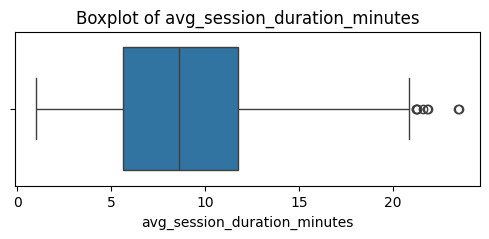

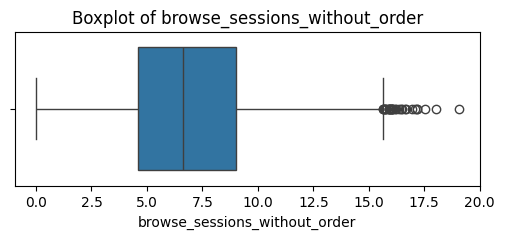

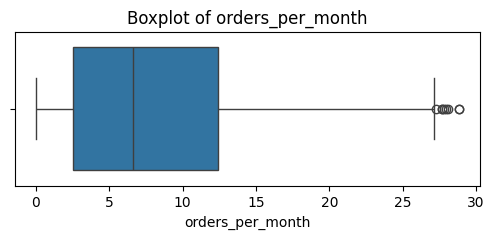

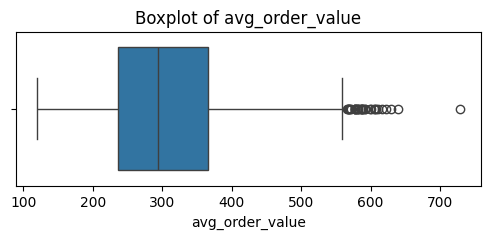

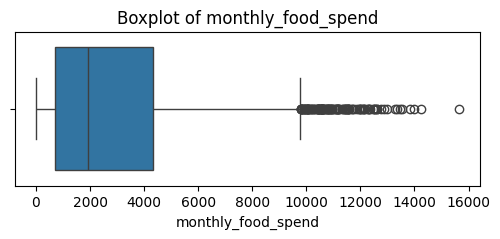

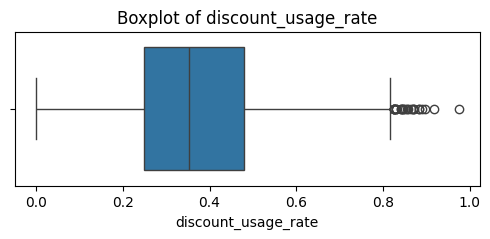

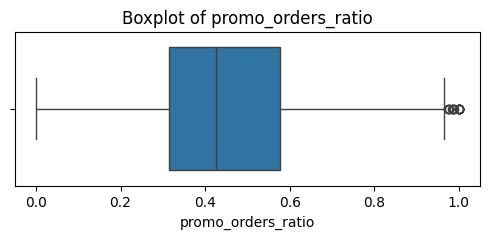

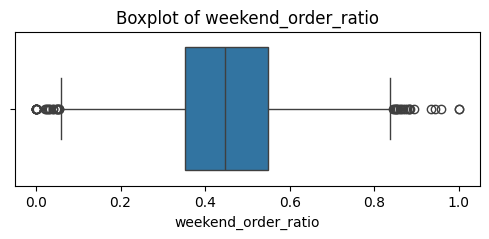

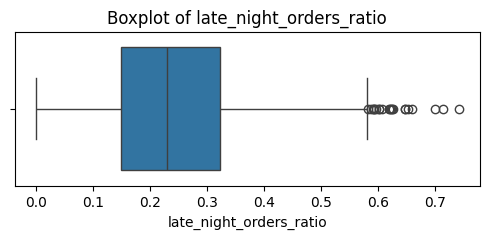

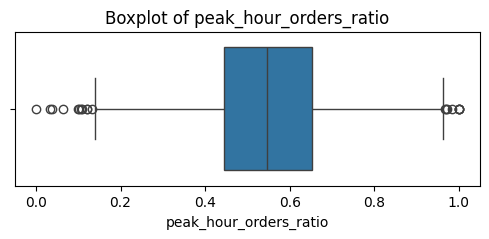

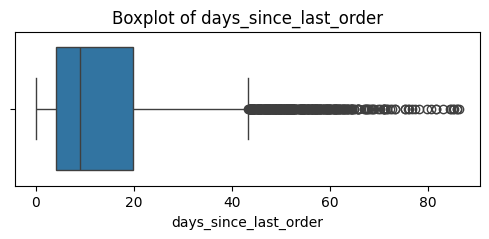

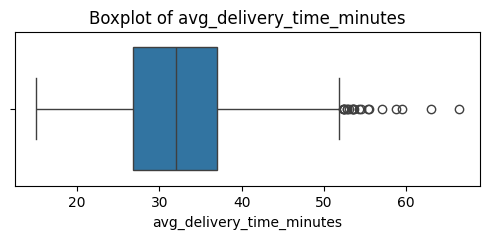

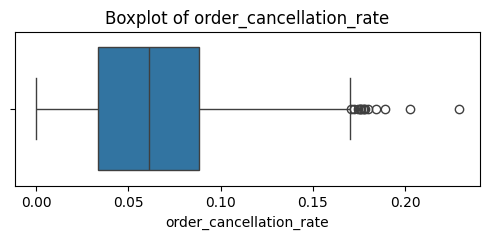

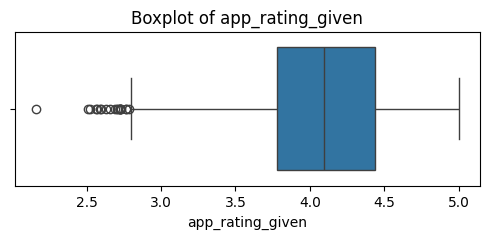

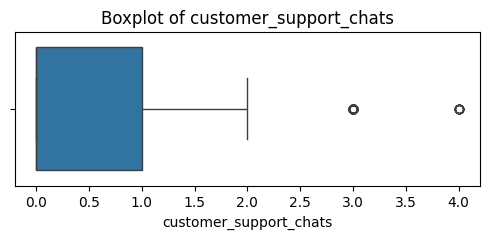

In [39]:
#b)
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df1[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [40]:
for col in numerical_cols:

    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df1[(df1[col] < lower) | (df1[col] > upper)]

    print(f"{col}")
    print("Number of Outliers:", len(outliers))
    print("-------------------------")

app_opens_per_month
Number of Outliers: 0
-------------------------
avg_session_duration_minutes
Number of Outliers: 9
-------------------------
browse_sessions_without_order
Number of Outliers: 32
-------------------------
orders_per_month
Number of Outliers: 8
-------------------------
avg_order_value
Number of Outliers: 34
-------------------------
monthly_food_spend
Number of Outliers: 121
-------------------------
discount_usage_rate
Number of Outliers: 26
-------------------------
promo_orders_ratio
Number of Outliers: 16
-------------------------
weekend_order_ratio
Number of Outliers: 44
-------------------------
late_night_orders_ratio
Number of Outliers: 21
-------------------------
peak_hour_orders_ratio
Number of Outliers: 19
-------------------------
days_since_last_order
Number of Outliers: 384
-------------------------
avg_delivery_time_minutes
Number of Outliers: 20
-------------------------
order_cancellation_rate
Number of Outliers: 14
-------------------------
app_ra

Method Used: Interquartile Range (IQR) and Boxplots.

Observation:

Outliers were found in numerical features such as monthly food spend, orders per month, and app opens per month.

Conclusion:

Since these outliers represent genuine high-engagement or high-spending users, they were retained rather than removed because they provide important information for analysis and modeling.

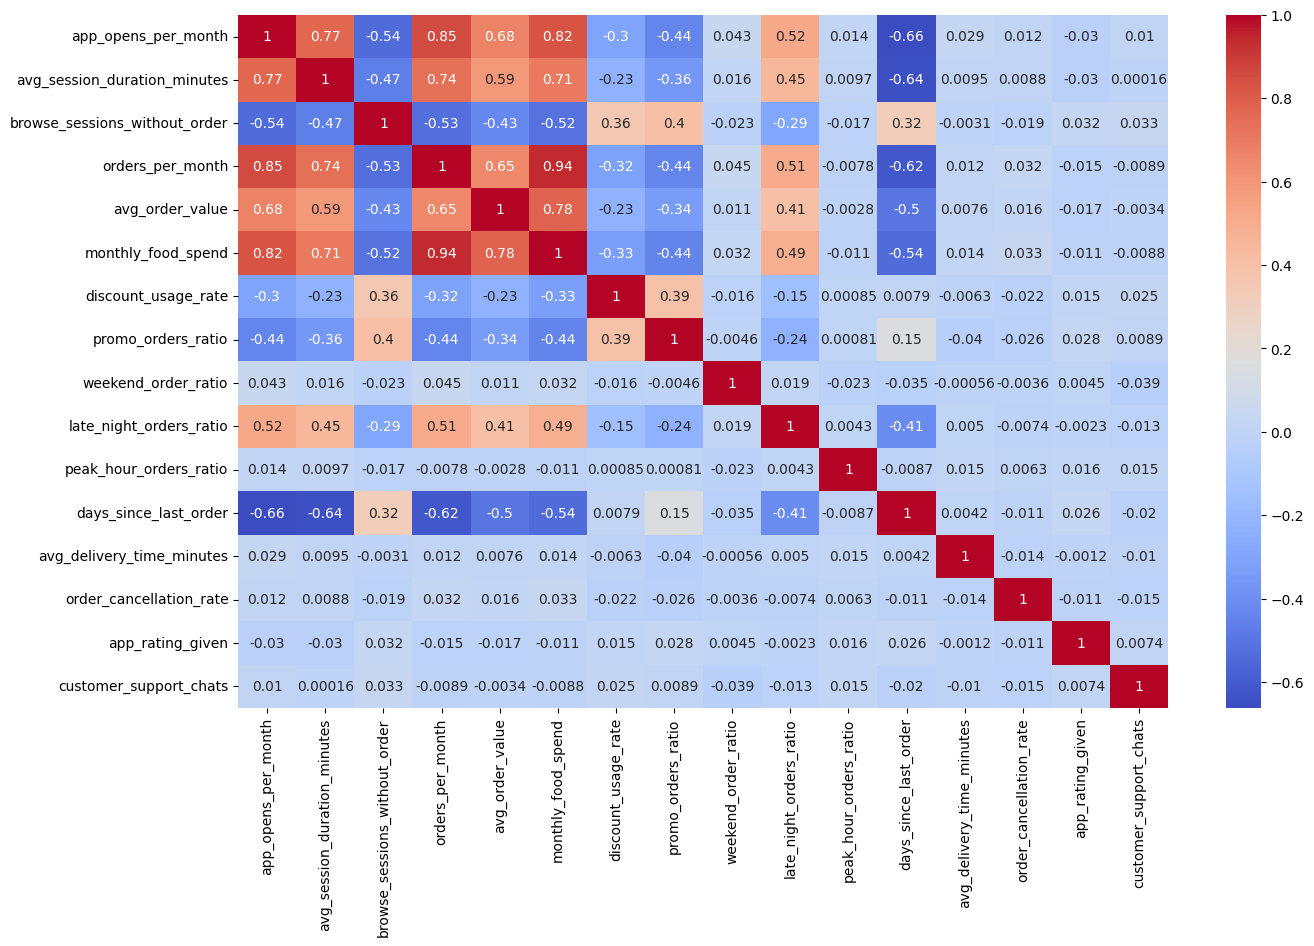

In [41]:
#c)
num = df1.select_dtypes(include='number')

plt.figure(figsize=(15,9))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.show()


In [42]:
correlation = df1.select_dtypes(include='number').corr()

correlation

,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,avg_order_value,monthly_food_spend,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
app_opens_per_month,1.000000,0.771464,-0.544739,0.852103,0.675363,0.824817,-0.303815,-0.440542,0.043375,0.520471,0.013929,-0.661946,0.028981,0.012477,-0.030430,0.010058
avg_session_duration_minutes,0.771464,1.000000,-0.466171,0.737533,0.588330,0.706548,-0.234430,-0.362024,0.015763,0.449062,0.009736,-0.643293,0.009539,0.008841,-0.029908,0.000162
browse_sessions_without_order,-0.544739,-0.466171,1.000000,-0.531947,-0.427679,-0.518701,0.360913,0.404477,-0.023075,-0.292119,-0.016743,0.321428,-0.003148,-0.018654,0.031526,0.032904
orders_per_month,0.852103,0.737533,-0.531947,1.000000,0.650927,0.935843,-0.315968,-0.439143,0.044896,0.509672,-0.007754,-0.618906,0.012403,0.032298,-0.015300,-0.008908
avg_order_value,0.675363,0.588330,-0.427679,0.650927,1.000000,0.780535,-0.229647,-0.338611,0.011484,0.405649,-0.002844,-0.500643,0.007580,0.016364,-0.017145,-0.003405
monthly_food_spend,0.824817,0.706548,-0.518701,0.935843,0.780535,1.000000,-0.327798,-0.442968,0.032038,0.493357,-0.011377,-0.541017,0.013500,0.033068,-0.010992,-0.008826
discount_usage_rate,-0.303815,-0.234430,0.360913,-0.315968,-0.229647,-0.327798,1.000000,0.390852,-0.016288,-0.149157,0.000846,0.007887,-0.006323,-0.022265,0.014714,0.024967
promo_orders_ratio,-0.440542,-0.362024,0.404477,-0.439143,-0.338611,-0.442968,0.390852,1.000000,-0.004644,-0.237186,0.000807,0.154149,-0.040222,-0.025801,0.028454,0.008936
weekend_order_ratio,0.043375,0.015763,-0.023075,0.044896,0.011484,0.032038,-0.016288,-0.004644,1.000000,0.019119,-0.023171,-0.035145,-0.000560,-0.003579,0.004479,-0.039263
late_night_orders_ratio,0.520471,0.449062,-0.292119,0.509672,0.405649,0.493357,-0.149157,-0.237186,0.019119,1.000000,0.004324,-0.412181,0.004977,-0.007352,-0.002334,-0.012860


Highly correlated features contain similar information.
They can give extra weight to the same pattern during clustering.
This may reduce cluster quality.
PCA can be used to reduce correlated features before applying K-Means.

In [43]:
from sklearn.preprocessing import StandardScaler

num = df1.select_dtypes(include='number')

scaler = StandardScaler()

scaled_data = scaler.fit_transform(num)

In [44]:
from sklearn.decomposition import PCA

pca = PCA()

pca_data = pca.fit_transform(scaled_data)

In [45]:
import numpy as np

np.cumsum(pca.explained_variance_ratio_)

array([0.34776862, 0.42727494, 0.49311475, 0.55691471, 0.61965669,
       0.68222961, 0.74254145, 0.80217385, 0.84394373, 0.88077747,
       0.91639457, 0.94797219, 0.96970046, 0.98780676, 0.99778601,
       1.        ])

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=12)

pca_data = pca.fit_transform(scaled_data)

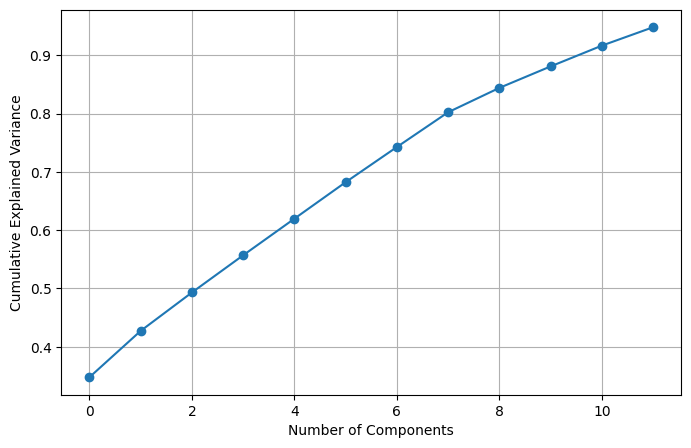

In [47]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)
plt.show()

PCA was applied after standardizing the numerical features. Based on the cumulative explained variance, 12 principal components were selected because they retain approximately 94.80% of the total variance. This preserves most of the original information while reducing the dimensionality of the dataset, making clustering more efficient

In [48]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    km = KMeans(n_clusters=i,
                random_state=42)

    km.fit(pca_data)

    wcss.append(km.inertia_)

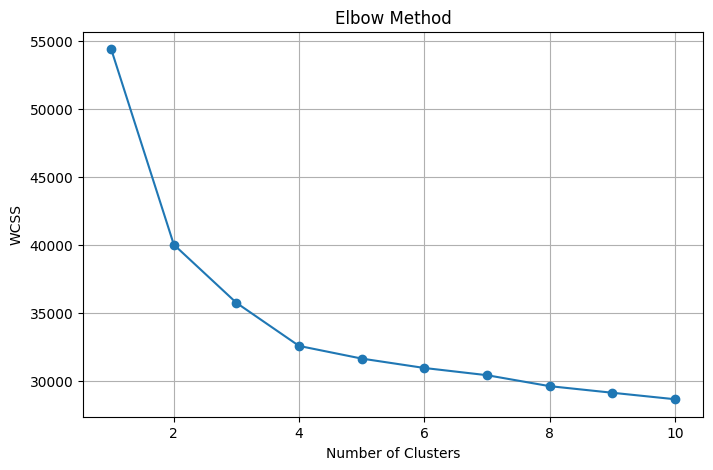

In [49]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)
plt.show()

In [50]:
kmeans = KMeans(n_clusters=4,
                random_state=42)

cluster = kmeans.fit_predict(pca_data)

df1['Cluster'] = cluster

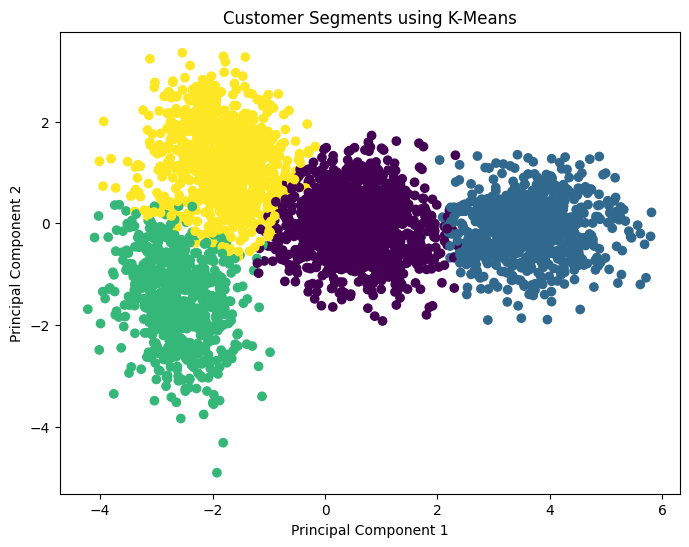

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df1['Cluster']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using K-Means")

plt.show()

In [52]:
df1.groupby('Cluster').mean(numeric_only=True)

,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,avg_order_value,monthly_food_spend,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
Cluster,,,,,,,,,,,,,,,,
0,34.975391,10.035231,5.937229,8.976433,316.461822,2848.201416,0.340441,0.397011,0.450370,0.248224,0.545334,7.051882,31.799782,0.063205,4.076274,0.601844
1,64.581413,14.129344,3.958233,18.081212,421.994081,7682.665618,0.255027,0.299923,0.459061,0.357816,0.552446,3.197257,32.341354,0.062932,4.104426,0.585806
2,6.190240,4.027553,8.150651,1.306316,220.759395,393.563934,0.295509,0.431087,0.443688,0.147362,0.541597,45.125039,32.187664,0.061998,4.099558,0.567164
3,17.559751,6.923666,9.925662,3.876245,258.688383,1041.648265,0.543455,0.657446,0.448225,0.203145,0.553592,15.505599,31.732453,0.060138,4.136391,0.644889


The Elbow Method was used to determine the optimal number of clusters.
K-Means grouped users with similar behaviour into different customer segments.
Each cluster represents a unique customer profile based on spending, ordering frequency, and app usage.
These customer segments can help businesses design targeted marketing campaigns, improve customer engagement, and provide personalized offers